In [1]:
PLANE = "yz"

%load_ext autoreload
%autoreload 2
%matplotlib inline

import math
import re
from pathlib import Path

import numpy as np

import dev
import matplotlib.pyplot as plt
import richio
from dev.datapaths import TDE_PARAMETERS
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

RESULT_ROOT = Path("/home/hey4/rich_tde/data/processed/ShockFinderEdissSelection")
CACHE_ROOT = RESULT_ROOT / "analysis" / "shock-locations"
CELL_ROOT = RESULT_ROOT / "analysis" / "per-cell"
PRESENTATION_ROOT = CACHE_ROOT / "presentation" / PLANE
PRESENTATION_ROOT.mkdir(parents=True, exist_ok=True)

FINAL_SNAPSHOTS = {"1e4": 151, "1e5": 161, "1e6": 1006}
MACH_MIN = {"1e4": 1.8, "1e5": 1.8, "1e6": 1.8}
POWER_MIN = {"1e4": 0.0, "1e5": 0.0, "1e6": 0.0}
DENSITY_DECADES = 6
DISSIPATION_DECADES = 6
PANEL_WIDTH = 3.9
DPI = 240
DENSITY_CMAP = "twilight"
SHOCK_CMAP = "inferno"
DISSIPATION_CMAP = "viridis"


In [2]:
def top_decades(values, decades):
    positive = values[np.isfinite(values) & (values > 0)]
    vmax = 10 ** (math.ceil(2 * np.log10(positive).max()) / 2)
    return vmax / 10**decades, vmax


def compact_colorbar(fig, ax, image, label, text_color="black"):
    cax = inset_axes(ax, width="50%", height="5%", loc="lower left", borderpad=0.8)
    bar = fig.colorbar(image, cax=cax, orientation="horizontal")
    bar.set_label(label, fontsize=9, labelpad=1, color=text_color)
    bar.outline.set_edgecolor(text_color)
    cax.tick_params(which="both", labelsize=8, length=2, pad=1, colors=text_color)
    cax.xaxis.set_label_position("top")


def needs_reference_frame(run, snap_path):
    if run == "1e6":
        return snap_path.parent.name == "TEMPTDE"
    return re.fullmatch(r"snap_\d+\.h5", snap_path.name) is not None


def load_plot_data(run):
    snapnum = FINAL_SNAPSHOTS[run]
    cache_path = CACHE_ROOT / run / "grids" / f"shock_locations_snap_{snapnum:04d}.npz"
    with np.load(cache_path) as cache:
        x_edges = np.asarray(cache[f"{PLANE}_x_edges"])
        y_edges = np.asarray(cache[f"{PLANE}_y_edges"])
        shock_x_edges = np.asarray(cache[f"{PLANE}_shock_x_edges"])
        shock_y_edges = np.asarray(cache[f"{PLANE}_shock_y_edges"])
        density_column = np.asarray(cache[f"{PLANE}_density_column"])
        dissipation_column = np.asarray(cache[f"{PLANE}_dissipation_column"])
        time_tfb = float(cache["time_tfb"])
        r_p_rsun = float(cache["r_p_rsun"])

    cell_path = CELL_ROOT / f"{run}_shock_dissipation_snap_{snapnum:04d}.npz"
    with np.load(cell_path) as cells:
        mach = np.asarray(cells["mach_T"])
        power = np.asarray(cells["shock_power_erg_s"])
        x = np.asarray(cells["x_Rsun"])
        y = np.asarray(cells["y_Rsun"])
        z = np.asarray(cells["z_Rsun"])
        snap_path = Path(str(cells["snap_path"].item()))

    if needs_reference_frame(run, snap_path):
        result_path = RESULT_ROOT / run / f"shockfinder_snap_{snapnum:04d}.npz"
        with np.load(result_path) as result:
            time = float(result["time_code"]) * richio.units.tscale
        m_bh, m_star, r_star = TDE_PARAMETERS[run]
        offset = dev.reference_frame_offset(
            t=time,
            Mbh=m_bh * richio.units.mscale,
            Mstar=m_star * richio.units.mscale,
            Rstar=r_star * richio.units.lscale,
            beta=1,
        )
        x += offset[0].to_value("Rsun")
        y += offset[1].to_value("Rsun")

    first, second = (x, y) if PLANE == "xy" else (y, z)
    selected = (
        np.isfinite(first)
        & np.isfinite(second)
        & (mach >= MACH_MIN[run])
        & (power >= POWER_MIN[run])
    )
    shock_count, _, _ = np.histogram2d(
        first[selected] / r_p_rsun,
        second[selected] / r_p_rsun,
        bins=(shock_x_edges, shock_y_edges),
    )

    return {
        "snapnum": snapnum,
        "time_tfb": time_tfb,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "shock_x_edges": shock_x_edges,
        "shock_y_edges": shock_y_edges,
        "density_column": density_column,
        "dissipation_column": dissipation_column,
        "shock_count": shock_count,
        "selected_shocks": int(selected.sum()),
        "retained_power": float(power[selected].sum() / power.sum()),
    }


1e4 M_sun | snap 151 | t/t_fb=2.1748 | M_T >= 1.8: 419147 cells, 99.566% shock power | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/shock-locations/presentation/yz/shock_locations_1e4_snap_0151_yz.png


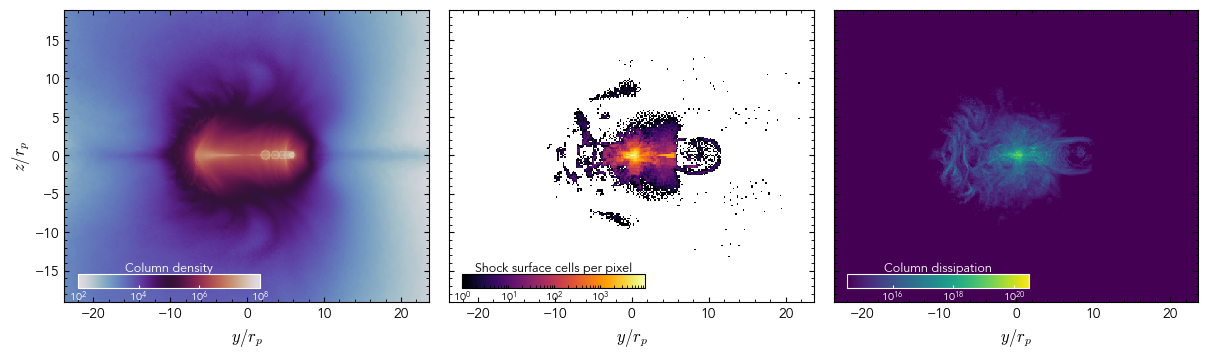

In [3]:
run = "1e4"
data = load_plot_data(run)

x_edges = data["x_edges"]
y_edges = data["y_edges"]
shock_x_edges = data["shock_x_edges"]
shock_y_edges = data["shock_y_edges"]
density_column = data["density_column"]
dissipation_column = data["dissipation_column"]
shock_count = data["shock_count"]

axis_names = ("x", "y") if PLANE == "xy" else ("y", "z")
aspect = (x_edges[-1] - x_edges[0]) / (y_edges[-1] - y_edges[0])
figure_height = max(2.2, PANEL_WIDTH / aspect + 0.55)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(3 * PANEL_WIDTH + 0.4, figure_height),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.045},
)

density_cmap = plt.get_cmap(DENSITY_CMAP).copy()
density_cmap.set_bad(density_cmap(0.0))
density_image = axes[0].pcolormesh(
    x_edges,
    y_edges,
    density_column.T,
    cmap=density_cmap,
    norm=LogNorm(*top_decades(density_column, DENSITY_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[0], density_image, "Column density", text_color="white")

visible_shocks = np.ma.masked_where(shock_count <= 0, shock_count)
shock_cmap = plt.get_cmap(SHOCK_CMAP).copy()
shock_cmap.set_bad("white")
shock_image = axes[1].pcolormesh(
    shock_x_edges,
    shock_y_edges,
    visible_shocks.T,
    cmap=shock_cmap,
    norm=LogNorm(vmin=1, vmax=max(2.0, float(shock_count.max()))),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[1], shock_image, "Shock surface cells per pixel")

dissipation_cmap = plt.get_cmap(DISSIPATION_CMAP).copy()
dissipation_cmap.set_bad(dissipation_cmap(0.0))
dissipation_image = axes[2].pcolormesh(
    x_edges,
    y_edges,
    dissipation_column.T,
    cmap=dissipation_cmap,
    norm=LogNorm(*top_decades(dissipation_column, DISSIPATION_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(
    fig,
    axes[2],
    dissipation_image,
    "Column dissipation",
    text_color="white",
)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(x_edges[[0, -1]])
    ax.set_ylim(y_edges[[0, -1]])
    ax.set_xlabel(rf"${axis_names[0]}/r_p$")
    ax.tick_params(labelsize=10)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)
axes[0].set_ylabel(rf"${axis_names[1]}/r_p$", labelpad=2)
fig.subplots_adjust(left=0.055, right=0.995, bottom=0.19, top=0.985)

output = PRESENTATION_ROOT / f"shock_locations_{run}_snap_{data['snapnum']:04d}_{PLANE}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {data['snapnum']} | t/t_fb={data['time_tfb']:.4f} | "
    f"M_T >= {MACH_MIN[run]:g}: {data['selected_shocks']} cells, "
    f"{data['retained_power']:.3%} shock power | {output}"
)
plt.show()


1e5 M_sun | snap 161 | t/t_fb=0.6058 | M_T >= 1.8: 855203 cells, 100.000% shock power | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/shock-locations/presentation/yz/shock_locations_1e5_snap_0161_yz.png


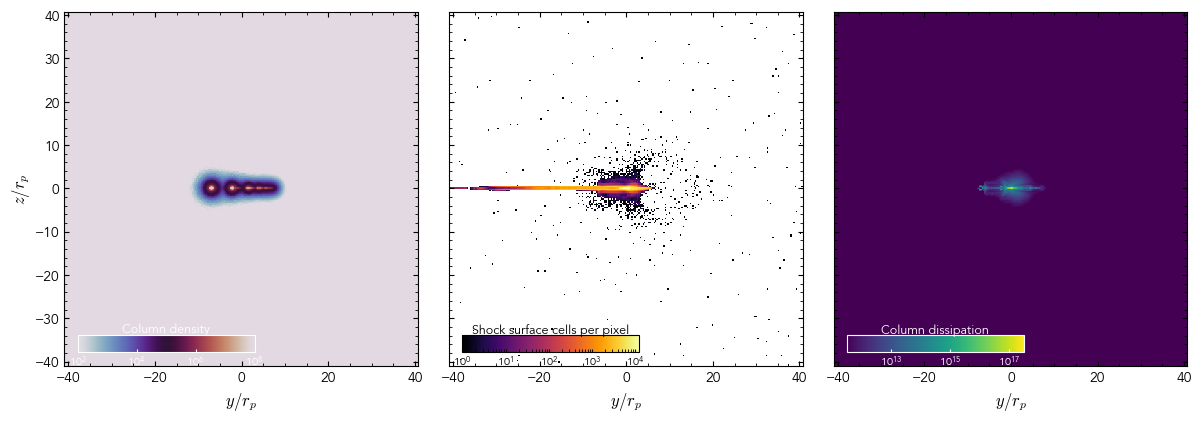

In [4]:
run = "1e5"
data = load_plot_data(run)

x_edges = data["x_edges"]
y_edges = data["y_edges"]
shock_x_edges = data["shock_x_edges"]
shock_y_edges = data["shock_y_edges"]
density_column = data["density_column"]
dissipation_column = data["dissipation_column"]
shock_count = data["shock_count"]

axis_names = ("x", "y") if PLANE == "xy" else ("y", "z")
aspect = (x_edges[-1] - x_edges[0]) / (y_edges[-1] - y_edges[0])
figure_height = max(2.2, PANEL_WIDTH / aspect + 0.55)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(3 * PANEL_WIDTH + 0.4, figure_height),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.045},
)

density_cmap = plt.get_cmap(DENSITY_CMAP).copy()
density_cmap.set_bad(density_cmap(0.0))
density_image = axes[0].pcolormesh(
    x_edges,
    y_edges,
    density_column.T,
    cmap=density_cmap,
    norm=LogNorm(*top_decades(density_column, DENSITY_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[0], density_image, "Column density", text_color="white")

visible_shocks = np.ma.masked_where(shock_count <= 0, shock_count)
shock_cmap = plt.get_cmap(SHOCK_CMAP).copy()
shock_cmap.set_bad("white")
shock_image = axes[1].pcolormesh(
    shock_x_edges,
    shock_y_edges,
    visible_shocks.T,
    cmap=shock_cmap,
    norm=LogNorm(vmin=1, vmax=max(2.0, float(shock_count.max()))),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[1], shock_image, "Shock surface cells per pixel")

dissipation_cmap = plt.get_cmap(DISSIPATION_CMAP).copy()
dissipation_cmap.set_bad(dissipation_cmap(0.0))
dissipation_image = axes[2].pcolormesh(
    x_edges,
    y_edges,
    dissipation_column.T,
    cmap=dissipation_cmap,
    norm=LogNorm(*top_decades(dissipation_column, DISSIPATION_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(
    fig,
    axes[2],
    dissipation_image,
    "Column dissipation",
    text_color="white",
)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(x_edges[[0, -1]])
    ax.set_ylim(y_edges[[0, -1]])
    ax.set_xlabel(rf"${axis_names[0]}/r_p$")
    ax.tick_params(labelsize=10)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)
axes[0].set_ylabel(rf"${axis_names[1]}/r_p$", labelpad=2)
fig.subplots_adjust(left=0.055, right=0.995, bottom=0.19, top=0.985)

output = PRESENTATION_ROOT / f"shock_locations_{run}_snap_{data['snapnum']:04d}_{PLANE}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {data['snapnum']} | t/t_fb={data['time_tfb']:.4f} | "
    f"M_T >= {MACH_MIN[run]:g}: {data['selected_shocks']} cells, "
    f"{data['retained_power']:.3%} shock power | {output}"
)
plt.show()


1e6 M_sun | snap 1006 | t/t_fb=1.5634 | M_T >= 1.8: 783002 cells, 99.928% shock power | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/shock-locations/presentation/yz/shock_locations_1e6_snap_1006_yz.png


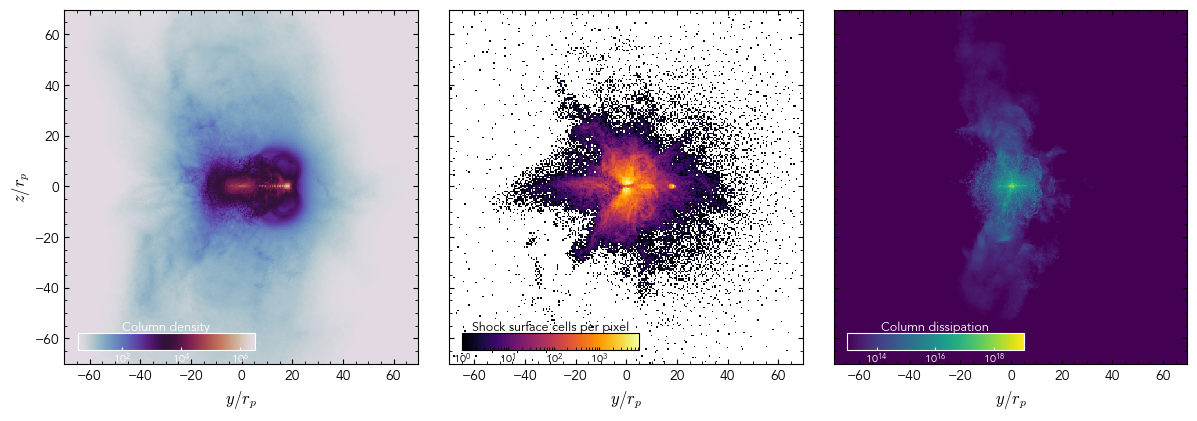

In [5]:
run = "1e6"
data = load_plot_data(run)

x_edges = data["x_edges"]
y_edges = data["y_edges"]
shock_x_edges = data["shock_x_edges"]
shock_y_edges = data["shock_y_edges"]
density_column = data["density_column"]
dissipation_column = data["dissipation_column"]
shock_count = data["shock_count"]

axis_names = ("x", "y") if PLANE == "xy" else ("y", "z")
aspect = (x_edges[-1] - x_edges[0]) / (y_edges[-1] - y_edges[0])
figure_height = max(2.2, PANEL_WIDTH / aspect + 0.55)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(3 * PANEL_WIDTH + 0.4, figure_height),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.045},
)

density_cmap = plt.get_cmap(DENSITY_CMAP).copy()
density_cmap.set_bad(density_cmap(0.0))
density_image = axes[0].pcolormesh(
    x_edges,
    y_edges,
    density_column.T,
    cmap=density_cmap,
    norm=LogNorm(*top_decades(density_column, DENSITY_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[0], density_image, "Column density", text_color="white")

visible_shocks = np.ma.masked_where(shock_count <= 0, shock_count)
shock_cmap = plt.get_cmap(SHOCK_CMAP).copy()
shock_cmap.set_bad("white")
shock_image = axes[1].pcolormesh(
    shock_x_edges,
    shock_y_edges,
    visible_shocks.T,
    cmap=shock_cmap,
    norm=LogNorm(vmin=1, vmax=max(2.0, float(shock_count.max()))),
    shading="flat",
    rasterized=True,
)
compact_colorbar(fig, axes[1], shock_image, "Shock surface cells per pixel")

dissipation_cmap = plt.get_cmap(DISSIPATION_CMAP).copy()
dissipation_cmap.set_bad(dissipation_cmap(0.0))
dissipation_image = axes[2].pcolormesh(
    x_edges,
    y_edges,
    dissipation_column.T,
    cmap=dissipation_cmap,
    norm=LogNorm(*top_decades(dissipation_column, DISSIPATION_DECADES)),
    shading="flat",
    rasterized=True,
)
compact_colorbar(
    fig,
    axes[2],
    dissipation_image,
    "Column dissipation",
    text_color="white",
)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(x_edges[[0, -1]])
    ax.set_ylim(y_edges[[0, -1]])
    ax.set_xlabel(rf"${axis_names[0]}/r_p$")
    ax.tick_params(labelsize=10)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)
axes[0].set_ylabel(rf"${axis_names[1]}/r_p$", labelpad=2)
fig.subplots_adjust(left=0.055, right=0.995, bottom=0.19, top=0.985)

output = PRESENTATION_ROOT / f"shock_locations_{run}_snap_{data['snapnum']:04d}_{PLANE}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {data['snapnum']} | t/t_fb={data['time_tfb']:.4f} | "
    f"M_T >= {MACH_MIN[run]:g}: {data['selected_shocks']} cells, "
    f"{data['retained_power']:.3%} shock power | {output}"
)
plt.show()
